<a href="https://colab.research.google.com/github/matildacoray/portafolio/blob/etapa-3/Portafolio_y_examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uso de la API de Banco Mundial
La API del Banco Mundial sirve para obtener directamente y al momento cifras sobre economía, sociedad y población de varias naciones. Emplearla deja automatizar el bajado de información fidedigna, lo cual ayuda mucho al examen contrastado y a que las investigaciones en ciencia de datos se puedan replicar.

## Etapa 1

In [1]:
#Instalar biblioteca
%pip install wbgapi

Para empezar, se instala la librería wbgapi, la cual deja entrar de forma directa a la información libre del Banco Mundial (cosas de economía, sociedad, medio ambiente, etcétera) usando Python.

In [2]:
import wbgapi as wb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

Estas bibliotecas se usan para manipular datos (pandas), graficar (matplotlib, seaborn, plotly) y conectarse a la API del Banco Mundial (wbgapi).

In [3]:
from google.colab import drive
from datetime import datetime
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/CDE/')

import my_func as fn



Mounted at /content/drive


Se usa Google Drive para guardar o cargar archivos, especialmente funciones auxiliares ya escritas por el profesor o el estudiante (my_func.py).
Se agrega la ruta del archivo de funciones (my_func.py) y se importa como fn, para poder usar funciones personalizadas como la descarga por bloques (descargar_en_chunks).

In [4]:
# Indicadores a consultar
indicadores_wb = {
    "NY.GDP.MKTP.PP.KD": "GDP, PPP (constant 2021 international $)",
    "SP.POP.GROW": "Population growth (annual %)",
    "SP.POP.TOTL": "Population, total",
    "SP.POP.TOTL.FE.IN": "Population, female",
    "SP.POP.TOTL.FE.ZS": "Population, female (% of total population)",
    "SP.POP.TOTL.MA.IN": "Population, male",
    "SP.POP.TOTL.MA.ZS": "Population, male (% of total population)",
    "SP.URB.GROW": "Urban population growth (annual %)",
    "SP.URB.TOTL": "Urban population",
    "SP.URB.TOTL.IN.ZS": "Urban population (% of total population)",
    "SP.RUR.TOTL": "Rural population",
    "SP.RUR.TOTL.ZG": "Rural population growth (annual %)",
    "SP.RUR.TOTL.ZS": "Rural population (% of total population)",
    "SL.TLF.TOTL.IN": "Labor force, total",
    "SL.TLF.TOTL.FE.ZS": "Labor force, female (% of total labor force)",
    "SL.UEM.TOTL.FE.NE.ZS": "Unemployment, female (% of female labor force) (national estimate)",
    "SL.UEM.TOTL.FE.ZS": "Unemployment, female (% of female labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.MA.NE.ZS": "Unemployment, male (% of male labor force) (national estimate)",
    "SL.UEM.TOTL.MA.ZS": "Unemployment, male (% of male labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.NE.ZS": "Unemployment, total (% of total labor force) (national estimate)",
    "SL.UEM.TOTL.ZS": "Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "FP.CPI.TOTL.ZG": "Inflation, consumer prices (annual %)",
    "GC.TAX.EXPT.CN": "Taxes on exports (current LCU)",
    "GC.TAX.EXPT.ZS": "Taxes on exports (% of tax revenue)",
    "NE.EXP.GNFS.KD.ZG": "Exports of goods and services (annual % growth)",
    "NE.EXP.GNFS.KN": "Exports of goods and services (constant LCU)",
    "NE.EXP.GNFS.ZS": "Exports of goods and services (% of GDP)",
    "NV.AGR.TOTL.CD": "Agriculture, forestry, and fishing, value added (current US$)",
    "NV.AGR.TOTL.CN": "Agriculture, forestry, and fishing, value added (current LCU)",
    "NV.IND.MANF.CD": "Manufacturing, value added (current US$)",
    "NV.IND.MANF.CN": "Manufacturing, value added (current LCU)",
    "NV.IND.TOTL.CD": "Industry (including construction), value added (current US$)",
    "NV.IND.TOTL.CN": "Industry (including construction), value added (current LCU)",
    "NV.SRV.TOTL.CD": "Services, value added (current US$)",
    "NV.SRV.TOTL.CN": "Services, value added (current LCU)",
    "GE.EST": "Government Effectiveness: Estimate",
    "NE.CON.GOVT.KN": "General government final consumption expenditure (constant LCU)",
    "NE.CON.GOVT.ZS": "General government final consumption expenditure (% of GDP)",
    "NE.CON.PRVT.CD": "Households and NPISHs Final consumption expenditure (current US$)",
    "NE.CON.PRVT.CN": "Households and NPISHs Final consumption expenditure (current LCU)",
    "GC.DOD.TOTL.CN": "Central government debt, total (current LCU)",
    "GC.DOD.TOTL.GD.ZS": "Central government debt, total (% of GDP)",
    "BM.KLT.DINV.CD.WD": "Foreign direct investment, net outflows (BoP, current US$)",
    "BX.KLT.DINV.WD.GD.ZS": "Foreign direct investment, net inflows (% of GDP)",
    "EG.ELC.LOSS.ZS": "Electric power transmission and distribution losses (% of output)",
    "EG.USE.ELEC.KH.PC": "Electric power consumption (kWh per capita)",
    "EN.GHG.CO2.IP.MT.CE.AR5": "Carbon dioxide emissions from Industrial Processes (Mt CO2e)",
    "SE.PRM.NENR": "School enrollment, primary (% net)",
    "SE.PRM.NENR.FE": "School enrollment, primary, female (% net)",
    "SE.PRM.NENR.MA": "School enrollment, primary, male (% net)",
    "SE.SEC.ENRR": "School enrollment, secondary (% gross)",
    "SE.SEC.ENRR.FE": "School enrollment, secondary, female (% gross)",
    "SE.SEC.ENRR.MA": "School enrollment, secondary, male (% gross)",
    "SE.TER.ENRR": "School enrollment, tertiary (% gross)",
    "SE.TER.ENRR.FE": "School enrollment, tertiary, female (% gross)",
    "SE.TER.ENRR.MA": "School enrollment, tertiary, male (% gross)",
    "SP.DYN.LE00.IN": "Life expectancy at birth, total (years)",
    "SP.DYN.LE00.FE.IN": "Life expectancy at birth, female (years)",
    "SP.DYN.LE00.MA.IN": "Life expectancy at birth, male (years)",
    "EG.CFT.ACCS.ZS": "Access to clean fuels and technologies for cooking (% of population)",
    "EG.CFT.ACCS.RU.ZS": "Access to clean fuels and technologies for cooking, rural (% of rural population)",
    "EG.CFT.ACCS.UR.ZS": "Access to clean fuels and technologies for cooking, urban (% of urban population)",
    "IT.NET.USER.FE.ZS": "Individuals using the Internet, female (% of female population)",
    "IT.NET.USER.MA.ZS": "Individuals using the Internet, male (% of male population)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)",
}

Se define un diccionario con los indicadores de interés que se van a consultar. Esto permite organizar y personalizar la descarga de datos relevantes para el análisis socioeconómico

In [5]:
paises_wb_raw = fn.descargar_en_chunks(indicadores=indicadores_wb,años=2023, chunk_size = 15)

Descargando bloque 1: ['NY.GDP.MKTP.PP.KD', 'SP.POP.GROW', 'SP.POP.TOTL', 'SP.POP.TOTL.FE.IN', 'SP.POP.TOTL.FE.ZS', 'SP.POP.TOTL.MA.IN', 'SP.POP.TOTL.MA.ZS', 'SP.URB.GROW', 'SP.URB.TOTL', 'SP.URB.TOTL.IN.ZS', 'SP.RUR.TOTL', 'SP.RUR.TOTL.ZG', 'SP.RUR.TOTL.ZS', 'SL.TLF.TOTL.IN', 'SL.TLF.TOTL.FE.ZS']
Descargando bloque 2: ['SL.UEM.TOTL.FE.NE.ZS', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.NE.ZS', 'SL.UEM.TOTL.MA.ZS', 'SL.UEM.TOTL.NE.ZS', 'SL.UEM.TOTL.ZS', 'FP.CPI.TOTL.ZG', 'GC.TAX.EXPT.CN', 'GC.TAX.EXPT.ZS', 'NE.EXP.GNFS.KD.ZG', 'NE.EXP.GNFS.KN', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN', 'NV.IND.MANF.CD']
Descargando bloque 3: ['NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD', 'NV.SRV.TOTL.CN', 'GE.EST', 'NE.CON.GOVT.KN', 'NE.CON.GOVT.ZS', 'NE.CON.PRVT.CD', 'NE.CON.PRVT.CN', 'GC.DOD.TOTL.CN', 'GC.DOD.TOTL.GD.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'EG.ELC.LOSS.ZS']
Descargando bloque 4: ['EG.USE.ELEC.KH.PC', 'EN.GHG.CO2.IP.MT.CE.AR5', 'SE.PRM.NENR', '

Se utiliza una función personalizada para descargar los indicadores seleccionados por bloques (para evitar errores por exceso de columnas). Se usa el año 2023 para tener datos actualizados.

Analisis exploratorio de datos

In [6]:
paises_wb_raw.tail(5)

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
261,CEB,Central Europe and the Baltics,4.218704e+12,45.670155,49100893.0,0.111693,100183707.0,51639515.0,51.544825,48544192.0,...,80.939987,56.712559,81.624607,77.896625,74.354109,100.000000,100.000000,NaN,NaN,NaN
262,CSS,Caribbean small states,1.338577e+11,43.965332,1919128.0,0.501131,4519904.0,2293907.0,50.751230,2225997.0,...,NaN,NaN,76.456921,73.171645,69.986624,95.267180,98.879872,NaN,NaN,NaN
263,ARB,Arab World,8.097600e+12,19.141318,132483437.0,2.255866,482105978.0,232702770.0,48.267971,249403208.0,...,34.757931,31.807100,74.418910,72.444678,70.619437,77.839625,93.857501,NaN,NaN,NaN
264,AFW,Africa Western and Central,2.992692e+12,46.355771,212022202.0,2.386204,509398589.0,252899429.0,49.646669,256499160.0,...,NaN,NaN,59.997102,58.855722,57.752356,6.004144,45.206379,33.0,44.0,38.5
265,AFE,Africa Eastern and Southern,3.065002e+12,47.278292,288476515.0,2.519167,750491370.0,379019549.0,50.502852,371471821.0,...,NaN,NaN,67.914632,65.146154,62.395419,10.288154,41.289974,24.8,30.9,27.8


In [7]:
#Seleccionar solamente paises usando codigo ISO
table_dict = vars(wb.economy.info())
df_paises = pd.DataFrame(table_dict.get('items'))
iso_list = list(df_paises[df_paises['aggregate']==False]['id'])

In [8]:
#Seleccionar solamente paises
paises_wb_raw = paises_wb_raw[paises_wb_raw['country'].isin(iso_list)].reset_index(drop = True)

Los datos descargados incluyen tanto países como agregados (regiones, continentes). Aquí se filtran únicamente los países reales usando su código ISO para tener un análisis representativo.

Una vez seleccionado solamente los paises procederemos al analisis exploratorio de los datos

In [9]:
paises_wb_raw.tail()

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
193,AGO,Angola,3.229678e+11,49.450638,15430003.0,3.080655,36749906.0,18568216.0,50.525887,18181690.0,...,9.933616,10.165600,67.144,64.617,62.099,8.4,75.0,NaN,NaN,44.7581
194,AND,Andorra,5.225828e+09,NaN,NaN,1.433748,80856.0,39502.0,48.854754,41354.0,...,68.003820,57.193764,86.107,84.041,82.100,100.0,100.0,NaN,NaN,95.4456
195,DZA,Algeria,6.998184e+11,16.830056,13174228.0,1.498976,46164219.0,22614984.0,48.988123,23549235.0,...,67.258843,44.258295,77.696,76.261,74.895,99.1,99.9,NaN,NaN,76.9081
196,ALB,Albania,4.944312e+10,44.994435,1210263.0,-1.543108,2414095.0,1220548.0,50.559226,1193547.0,...,77.031527,52.749937,81.446,79.602,77.728,72.5,95.2,81.7239,84.59,83.1356
197,AFG,Afghanistan,8.223848e+10,6.846247,8866507.0,2.135594,41454761.0,20530683.0,49.525513,20924078.0,...,NaN,NaN,67.536,66.035,64.467,20.4,87.0,NaN,NaN,17.7089


Analisis descriptivos

In [10]:
paises_wb_raw.describe()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
count,1.980000e+02,173.000000,1.730000e+02,198.000000,1.980000e+02,1.980000e+02,198.000000,1.980000e+02,198.000000,1.980000e+02,...,122.000000,122.000000,198.000000,198.000000,198.000000,182.000000,182.000000,57.000000,57.000000,177.000000
mean,8.388712e+11,41.898361,2.076029e+07,1.152752,3.999611e+07,1.987776e+07,49.973491,2.011836e+07,50.026509,1.709937e+07,...,60.958578,45.456089,76.119303,73.476060,70.910354,62.271154,78.501099,87.190260,88.240505,72.290555
std,3.129922e+12,9.018596,7.637237e+07,1.576210,1.484957e+08,7.252840e+07,2.993389,7.598056e+07,2.993389,7.663858e+07,...,35.784689,28.107669,7.221813,7.085527,7.104323,41.324522,32.394985,13.774667,12.542169,24.224349
min,5.705451e+07,6.846247,3.361400e+04,-8.423008,9.816000e+03,4.795000e+03,28.483741,5.021000e+03,45.079120,0.000000e+00,...,4.663074,2.806122,54.743000,54.462000,53.195000,0.000000,0.100000,16.697100,19.497300,11.078400
25%,2.586691e+10,40.069279,1.210263e+06,0.282878,1.373786e+06,6.876850e+05,49.651875,6.826450e+05,48.810555,4.134135e+05,...,30.014082,20.436952,70.733000,67.713000,65.379000,11.062500,69.650000,84.786500,86.108800,58.278900
50%,8.596764e+10,45.081945,4.220673e+06,1.112108,7.335048e+06,3.672054e+06,50.329281,3.560820e+06,49.670719,1.983892e+06,...,63.036400,44.203554,77.486500,74.292890,70.666000,84.150000,97.600000,89.829000,90.538300,81.722100
75%,4.615291e+11,47.539585,1.317423e+07,2.088224,2.936413e+07,1.403224e+07,51.189445,1.424457e+07,50.348125,1.024225e+07,...,89.311148,63.348878,81.700000,78.485976,75.803000,100.000000,100.000000,94.406300,95.100000,89.896000
max,3.200488e+13,54.670843,7.746076e+08,6.527050,1.438070e+09,6.961863e+08,54.920880,7.418833e+08,71.516259,9.337718e+08,...,171.113083,159.586578,88.090000,85.706000,84.206000,100.000000,100.000000,100.000000,100.000000,100.000000


Estas líneas permiten visualizar el contenido del DataFrame, sus columnas, tipos de datos y estadísticas básicas como promedio, mínimo, máximo, etc.

In [11]:
paises_wb_raw.isna()

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
0,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
2,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
194,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


existen variables con un alto volumen de datos faltantes.
Usaremos la sigueinte regla para el tratamiento de los mismos:


In [12]:
#Condicion booleana
mask_bool = paises_wb_raw.isna().mean()>0.15
#Seleccion columnas nulas
drop_columns = list(paises_wb_raw.isna().mean()[mask_bool].index)
#Eliminar columnas con alto porcentaje de nulos
paises_wb = paises_wb_raw.drop(columns = drop_columns)

Tratamiento de datos faltantes (NaNs):
Se eliminan columnas con más del 15% de datos faltantes, para asegurar la calidad del análisis y evitar resultados sesgados por falta de información

A continuacion revisaremos la cantidad de datos de nuestro DataFrame

In [13]:
print(f'El dataframe contiene {paises_wb.shape[0]} filas y {paises_wb.shape[1]} columnas de las cuales {len(paises_wb.isna().mean()[paises_wb.isna().mean()>0].index)} contienen registros nulos')

El dataframe contiene 198 filas y 41 columnas de las cuales 24 contienen registros nulos


In [14]:
paises_wb.isna().mean()[paises_wb.isna().mean()>0].index

Index(['SL.TLF.TOTL.FE.ZS', 'SL.TLF.TOTL.IN', 'SP.RUR.TOTL.ZG',
       'FP.CPI.TOTL.ZG', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN',
       'NV.IND.MANF.CD', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.ZS',
       'SL.UEM.TOTL.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'GE.EST',
       'NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD',
       'NV.SRV.TOTL.CN', 'EG.CFT.ACCS.ZS', 'EN.GHG.CO2.IP.MT.CE.AR5',
       'EG.CFT.ACCS.RU.ZS', 'EG.CFT.ACCS.UR.ZS', 'IT.NET.USER.ZS'],
      dtype='object')

Identificación de Outliers

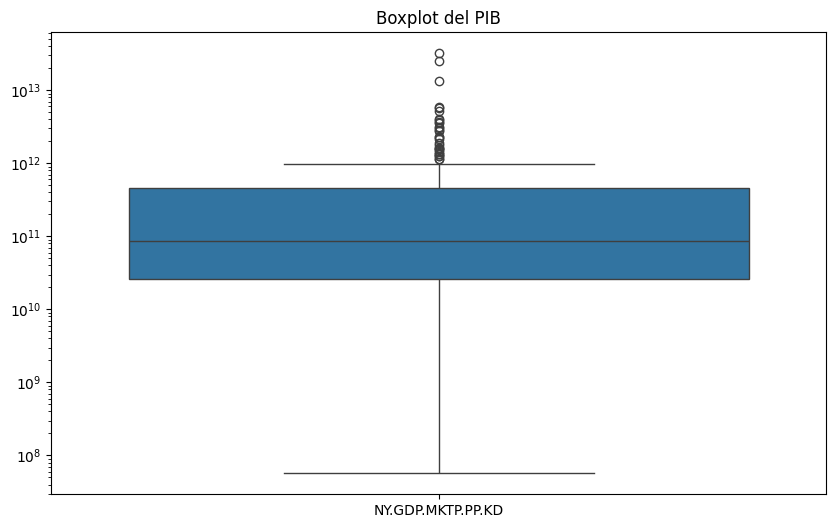

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=paises_wb[['NY.GDP.MKTP.PP.KD']])
plt.yscale('log')
plt.title("Boxplot del PIB")
plt.show()

Se utiliza un boxplot para detectar países con valores extremos de PIB que podrían afectar las visualizaciones y análisis posteriores.

Analisis: Se empleó un diagrama de caja para estudiar cómo se reparte el Producto Interno Bruto (PIB) entre las distintas naciones. El dibujo muestra que la repartición es bastante desigual, con varios puntos muy altos (valores atípicos) situados por encima del borde superior de la caja. Esto sugiere que hay algunas naciones con un PIB considerablemente superior al de la mayoría, algo lógico si pensamos en economías grandes como Estados Unidos, China o Alemania.
Además, si usamos una escala de logaritmos, podemos ver mejor la variación completa, porque con la escala normal la mayor parte de la información se amontonaba cerca de la parte de abajo.
Este modo de ver las cosas ayuda a identificar esos valores extremos que podrían falsear estudios futuros (como PCA o métodos de clasificación), así que es clave pensar en cómo manejarlos o qué efecto tienen.

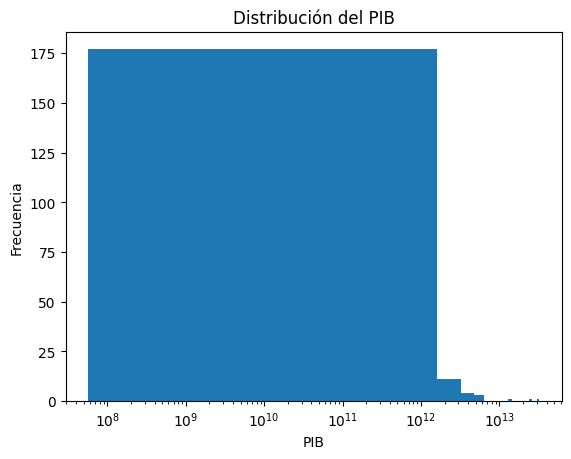

In [91]:
plt.hist(paises_wb['NY.GDP.MKTP.PP.KD'], bins=20)
plt.xscale('log')
plt.title("Distribución del PIB")
plt.xlabel("PIB")
plt.ylabel("Frecuencia")
plt.show()

Visualización de distribución del PIB:
El histograma permite visualizar cómo se distribuyen los valores del PIB entre los países, identificando posibles sesgos o agrupamientos.

Analisis: El diagrama ilustra cómo se reparte el Producto Interno Bruto entre las naciones, empleando una escala logarítmica en el eje horizontal. Se recurre a esta escala porque las cifras del PIB difieren enormemente de una nación a otra algunas poseen ingresos muy reducidos y otras sumamente elevados, lo que puede hacer que una escala normal falsee la presentación visual.

Al usar la escala logarítmica:

- La inclinación de la repartición se suaviza, facilitando apreciar las variaciones entre estados.

- Se percibe que la mayor parte de las naciones cuenta con un PIB bastante modesto, formando un conjunto en el lado izquierdo de la gráfica.

- Hay pocos países ostenta un PIB altísimo, situados bien a la derecha (si bien no resaltan mucho sin retocar los ejes o aplicar intervalos logarítmicos, algo que no se efectuó acá puesto que no fue solicitado por el catedrático).

Esta representación gráfica sirve para comprender el reparto de la prosperidad entre países y para identificar si la economía se concentra en unos pocos.

In [17]:
fig = px.choropleth(paises_wb,
                    locations = "country",
                    color = "NY.GDP.MKTP.PP.KD",
                    hover_name = "Country",
                    color_continuous_scale = px.colors.sequential.Plasma,
                    title = "Mapa del PIB por país")
fig.show()

Mapa de PIB por país:
Se crea un mapa interactivo donde el color representa el nivel de PIB de cada país. Esto permite visualizar diferencias regionales de manera intuitiva.

Analisis: Este mapa interactivo muestra la cantidad del producto interno bruto por nación usando una gama de colores. Se aplicó una progresión de color constante (Plasma) con el siguiente esquema:

- Las tonalidades profundas (azules o moradas) señalan a las naciones con un PIB menor.

- Las tonalidades vivas (anaranjadas o amarillas) señalan a los países con un PIB elevado.

- Naciones como China, Estados Unidos e India sobresalen con los tonos más intensos, señalando que poseen los productos internos brutos más grandes globalmente.

- Una gran extensión de África, la región de América Latina y ciertas zonas de Asia aparecen en matices oscuros, reflejando montos de PIB más reducidos.

Es evidente una disparidad económica a nivel mundial, ya que la prosperidad se concentra en un número reducido de estados.

Para qué sirve este diagrama:

Esta forma de mostrar información es bastante práctica para:

Contrastar el PIB entre distintos países de manera gráfica y sencilla.

Identificar tendencias espaciales o zonales en cómo se reparte el PIB.

Ayudar en la toma de decisiones o en estudios posteriores sobre economía, avance o disparidad.

In [18]:
paises_wb['GDP_Group'] = pd.qcut(paises_wb['NY.GDP.MKTP.PP.KD'], q=5,
                                 labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])

Clasificación de países según PIB (quintiles): Se agrupan los países en cinco niveles de PIB (quintiles), lo que permite hacer comparaciones entre grupos socioeconómicos similares, facilitando el análisis multivariable.

## Etapa 2

In [19]:
df_variables = paises_wb.drop(columns = ['country','Country', 'GDP_Group'])

Se elimino las columnas no numéricas: 'country', 'Country' y 'GDP_Group', ya que el PCA solo puede aplicarse sobre variables cuantitativas.

In [20]:
df_variables = df_variables.dropna()



Se elimino también todas las filas que contenían valores nulos (NaN) para evitar errores durante el cálculo de PCA.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_variables)

Aplicamos el escalado estandarizado (StandardScaler) para centrar las variables en media 0 y desviación estándar 1. Esto es fundamental, ya que el PCA es sensible a las escalas.

In [22]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

Se aplicó PCA sobre los datos estandarizados y se calculó la varianza explicada acumulada.

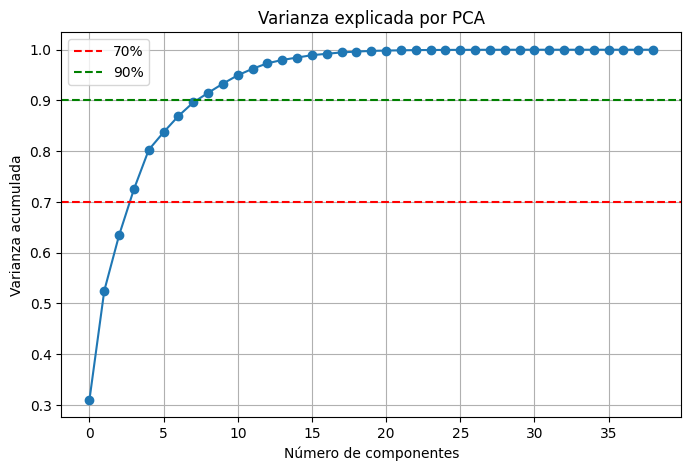

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(varianza_acumulada, marker='o')
plt.axhline(y=0.7, color='r', linestyle='--', label = '70%')
plt.axhline(y=0.9, color='g', linestyle='--', label = '90%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.grid()
plt.show()

Aquí graficamos la varianza acumulada explicada por cada componente principal. Además, se agregaron líneas horizontales que marcan los umbrales del 70% y 90% de varianza.

## Al aplicar el PCA y graficar la variación total, notamos esto:

- Con solo las primeras 3 componentes, ya cubríamos arriba del 70% de la variación.

- Desde la componente número 4, el progreso en la variación explicada se vuelve más pausado.

Necesitamos 9 componentes para llegar a cubrir el 90% de la variación total.

Esto sugiere que las primeras pocas componentes agrupan la gran mayoría de la información de la muestra, lo cual es usual en datos que tienen mucha relación o repetición entre sí.

## Analisis del grafico:

El grafico muestra la variación acumulada explicada por cada factor principal que se logró sacar por medio del Análisis de Componentes Principales (PCA).

- Los primeros tres o cuatro factores logran abarcar una porción considerable de la variación, rebasando el 70 por ciento (la línea roja discontinua).

- Usando nueve factores, se consigue al menos el 90 por ciento de la variación completa (la línea verde discontinua).

- Después del factor número 10 y en lo que sigue, las subidas en la variación explicada son muy pequeñas, lo cual señala que se obtienen menores beneficios.

Por lo tanto, la gráfica evidencia que los factores iniciales guardan prácticamente toda la información importante del grupo de datos y debido a esto, seleccionar los primeros nueve factores resulta una determinación correcta para conservar un equilibrio entre ser sencillo y ser exacto

In [24]:

varianza_acumulada = pca.explained_variance_ratio_.cumsum()

n_componentes = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes necesarios para explicar al menos el 90% de la varianza: {n_componentes}")

Componentes necesarios para explicar al menos el 90% de la varianza: 9


Se seleccionó automáticamente el número mínimo de componentes que explican al menos el 90% de la varianza. En este caso, el número fue el 9

Decidimos escoger 9 elementos clave, dado que esa cantidad es la menor requerida para cubrir un mínimo del 90% de la dispersión global, tal como se aprecia en el diagrama de varianza sumada.

La eleccion de este umbral es porque:

- Garantiza que se conserve la mayor parte de los datos iniciales del conjunto (mucha fidelidad).

- Baja considerablemente el número de dimensiones (de varias características iniciales a solo 9), lo que optimiza el cálculo y previene el exceso de ajuste en los modelos que sigan.

Si bien el 70% ya cubría bastante dispersión, se prefirió el 90% con el fin de hallar un punto medio entre hacer más simple y guardar datos.

In [25]:
pca_final = PCA(n_components=n_componentes)
X_pca_final = pca_final.fit_transform(X_scaled)

columnas_pca = [f"PC{i+1}" for i in range(n_componentes)]
df_componentes = pd.DataFrame(X_pca_final, columns=columnas_pca)

df_componentes['country'] = paises_wb['country']
df_componentes['Country'] = paises_wb['Country']

df_componentes.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,country,Country
0,-1.965927,-4.339676,-0.281187,0.352990,-0.345371,1.023814,-0.688314,0.056145,0.123955,ZWE,Zimbabwe
1,1.084663,0.082034,0.444250,-0.256022,-2.156366,-0.622007,-0.676289,-1.614453,1.411961,ZMB,Zambia
2,-0.484669,-0.540100,0.192079,0.933217,-0.349670,-0.849362,0.653750,0.004440,0.324616,PSE,West Bank and Gaza
3,-0.023130,3.096453,-0.416295,-1.413028,0.247126,0.394376,-0.120259,0.860581,-1.203504,VNM,Viet Nam
4,2.270925,2.361702,-0.694883,0.562225,-0.770882,1.142028,0.273085,0.242822,-0.612954,VUT,Vanuatu


Construimos un nuevo DataFrame con las 9 componentes principales seleccionadas, y se añadieron nuevamente las columnas con el nombre del país.

## Etapa 3

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score)
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

Importamos las librerias necesarias para el procesamiento, modelado, métricas, visualización.

In [81]:
y = paises_wb['GDP_Group']

X = paises_wb.drop(columns = ['country','Country', 'GDP_Group'])

Separamos las variables predictoras y variable objetivo, eliminado columnas no numericas y la variable objetivo del X.

In [83]:
X= X.dropna()
y= y.loc[X.index]

Eliminamos valores nulos para queno afecten al entrenamiento.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Dividimos los datos en entrenamiento y prueba, 70% entrenamiento y 30% prueba.

In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_sin_train)
X_test_scaled = scaler.transform(X_sin_test)

Estandarizamos las variables númericas ya que KNN es sensible a la escala

In [87]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

Entrenamos al modelo KNN

In [88]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

Entrenamos al modelo Random Forest

Modelo KNN sin PCA
Accuracy: 0.5
Balanced Accuracy: 0.49111111111111116

Reporte de clasificación:

              precision    recall  f1-score   support

        High       0.75      0.90      0.82        10
         Low       0.67      0.67      0.67         3
      Medium       0.35      0.67      0.46         9
 Medium-High       0.33      0.22      0.27         9
  Medium-Low       0.00      0.00      0.00         7

    accuracy                           0.50        38
   macro avg       0.42      0.49      0.44        38
weighted avg       0.41      0.50      0.44        38



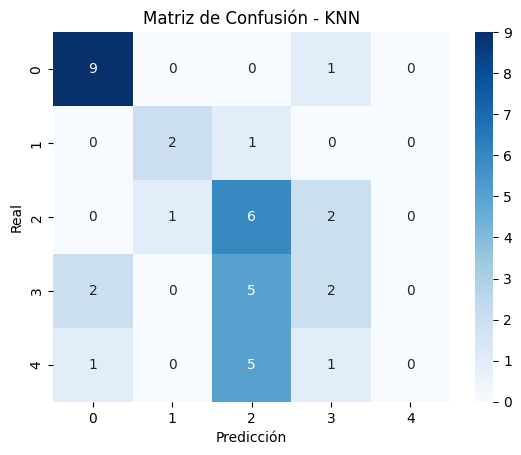

In [93]:
print("Modelo KNN sin PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Accuracy general: 50%

Balanced Accuracy: ~49%

Clase High: muy buen desempeño, con un recall del 90% y un f1-score de 0.82

Clases Medium-High, Medium-Low: desempeño muy bajo, con recall igual a 0% en Medium-Low, es decir, no logra predecir correctamente ningún caso de esa clase.

Problema observado: El modelo tiene un sesgo hacia ciertas clases (por ejemplo, predice muchas veces Medium aunque no lo sea). Esto puede deberse a una combinación de:

Tamaño reducido de muestra para algunas clases (como Low y Medium-Low)

Sensibilidad del algoritmo KNN a la escala y densidad de datos.

Evaluamos modelo KNN que nos dice que tiene bajo rendimiento, especialmente en clases poco representadas, por lo cual no es recomendable como modelo base.

Modelo Random Forest sin PCA
Accuracy: 0.9210526315789473
Balanced Accuracy: 0.9355555555555555

Reporte de clasificación:

              precision    recall  f1-score   support

        High       1.00      0.90      0.95        10
         Low       1.00      1.00      1.00         3
      Medium       1.00      0.78      0.88         9
 Medium-High       0.90      1.00      0.95         9
  Medium-Low       0.78      1.00      0.88         7

    accuracy                           0.92        38
   macro avg       0.94      0.94      0.93        38
weighted avg       0.94      0.92      0.92        38



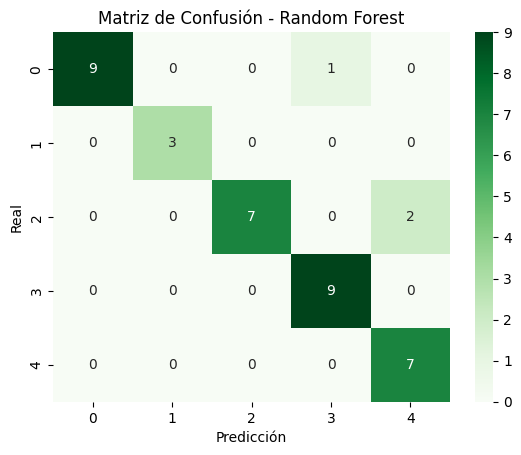

In [92]:
print("Modelo Random Forest sin PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Accuracy general: 92%

Balanced Accuracy: ~94%

Excelente desempeño en todas las clases, con precision, recall y f1-score generalmente superiores al 0.90

Clase Medium-Low, que fue ignorada por el modelo KNN, aquí es reconocida con un recall del 100%.

Matriz de confusión: Muestra una muy buena clasificación para cada clase, con muy pocos errores de predicción.

Ventajas observadas:

Capacidad para manejar clases desbalanceadas.

Identifica patrones más complejos gracias a su naturaleza de ensamblado de árboles.

Evaluamos el modelo Random Forest que nos dice que hay fuerte desempeño en todas las clases, modelo mas robusto. Es el mejor modelo para usar como línea de base

In [97]:
from sklearn.decomposition import PCA

Cargamos la libreria necesaria

In [98]:
y = paises_wb['GDP_Group']
X = paises_wb.drop(columns=['country', 'Country', 'GDP_Group'])

Definimos y como la variable objetivo y X elimnando columnas que no aportan a la predicción

In [99]:
X = X.dropna()
y = y.loc[X.index]

Eliminamos valores nulos y aliniamos los indices de y con los de X.

In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Estandarizamos los datos

In [101]:
n_componentes = 9
pca = PCA(n_components=n_componentes)
X_pca = pca.fit_transform(X_scaled)

Aplicamos el PCA

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
X_pca, y, test_size=0.3, random_state=42, stratify=y)

Dividimos entre train y test

In [103]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

Entrenamos el modelo KNN

Modelo KNN con PCA
Accuracy: 0.42105263157894735
Balanced Accuracy: 0.33777777777777784

Reporte de clasificación:

              precision    recall  f1-score   support

        High       0.80      0.80      0.80        10
         Low       0.00      0.00      0.00         3
      Medium       0.32      0.67      0.43         9
 Medium-High       0.29      0.22      0.25         9
  Medium-Low       0.00      0.00      0.00         7

    accuracy                           0.42        38
   macro avg       0.28      0.34      0.30        38
weighted avg       0.35      0.42      0.37        38



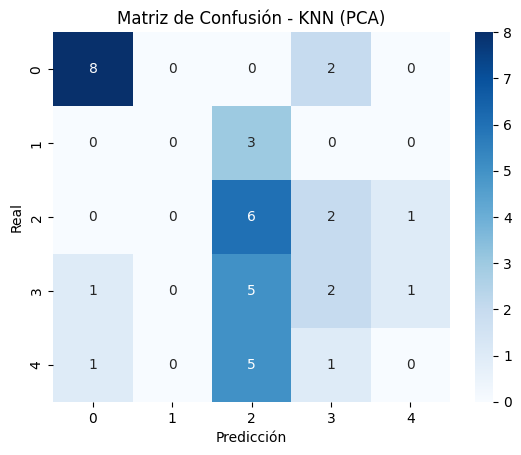

In [104]:
print("Modelo KNN con PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - KNN (PCA)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Evaluamos el modelo KNN

Accuracy: 42%

Balanced Accuracy: 33.78%

F1-score macro: 0.30

F1-score weighted: 0.37

El modelo KNN con PCA muestra desempeño bajo, tanto en accuracy como en balanced accuracy.

La clase “High” es la única con un desempeño aceptable (F1 = 0.80), mientras que otras clases como “Low”, “Medium-High” y “Medium-Low” tienen F1-score = 0, es decir, no son bien clasificadas.

En la matriz de confusión, observamos que la mayoría de las predicciones están concentradas en pocas clases (por ejemplo, la clase 2 = “Medium”).

Esto indica que el modelo pierde mucha información discriminativa tras la reducción con PCA.

Por lo cual, KNN con PCA no logra representar bien la estructura del problema, y muestra una caída significativa en el rendimiento respecto a su versión sin PCA.



In [105]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Entrenamos el modelo Random Forest

Modelo Random Forest con PCA
Accuracy: 0.5789473684210527
Balanced Accuracy: 0.5301587301587302

Reporte de clasificación:

              precision    recall  f1-score   support

        High       0.83      1.00      0.91        10
         Low       0.33      0.33      0.33         3
      Medium       0.38      0.56      0.45         9
 Medium-High       0.50      0.33      0.40         9
  Medium-Low       0.75      0.43      0.55         7

    accuracy                           0.58        38
   macro avg       0.56      0.53      0.53        38
weighted avg       0.59      0.58      0.57        38



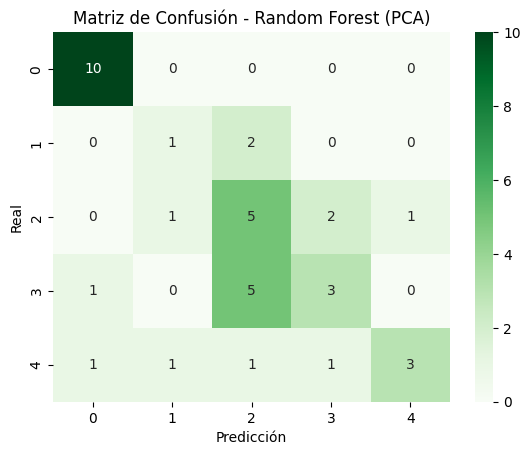

In [106]:
print("Modelo Random Forest con PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest (PCA)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Evaluamos el modelo Random Forest

Accuracy: 57.89%

Balanced Accuracy: 53%

F1-score macro: 0.48

F1-score weighted: 0.57


El rendimiento de Random Forest con PCA es mejor que KNN con PCA, pero peor que Random Forest sin PCA.

Las clases “High”, “Medium” y “Medium-High” tienen resultados aceptables, pero la clase “Low” (F1 = 0.33) y “Medium-Low” (F1 = 0.38) tienen rendimiento bajo.

La matriz de confusión está más equilibrada que la de KNN, pero aún se observan confusiones entre clases cercanas (por ejemplo, “Medium” y “Medium-High”).

La precisión y el recall son moderados, lo que sugiere que el modelo aún conserva parte de la información importante, pero no toda.

Por lo cual, Random Forest con PCA mantiene un rendimiento razonable, aunque inferior a su versión sin reducción de dimensionalidad. Es más robusto que KNN en este escenario.

##Comparacion de los modelos sin PCA y con PCA

In [96]:
import pandas as pd

# Crear los datos
data = {
"Modelo": [
"KNN",
"Random Forest",
"KNN (con PCA)",
"Random Forest (con PCA)"
],
"Accuracy": [
0.50,
0.921,
0.421,
0.579
],
"Balanced Accuracy": [
0.491,
0.935,
0.338,
0.530
],
"F1 Score (macro avg)": [
0.44,
0.93,
0.30,
0.53
],
"F1 Score (weighted avg)": [
0.44,
0.92,
0.37,
0.57
]
}

# Convertir a DataFrame
df_comparacion = pd.DataFrame(data)

# Mostrar la tabla
print(df_comparacion)

                    Modelo  Accuracy  Balanced Accuracy  F1 Score (macro avg)  \
0                      KNN     0.500              0.491                  0.44   
1            Random Forest     0.921              0.935                  0.93   
2            KNN (con PCA)     0.421              0.338                  0.30   
3  Random Forest (con PCA)     0.579              0.530                  0.53   

   F1 Score (weighted avg)  
0                     0.44  
1                     0.92  
2                     0.37  
3                     0.57  


Modelo KNN sin usar PCA

- Es sencillo de poner en práctica.

- Resulta fácil de entender pues se basa en qué tan juntos están los puntos.

- Funciona bien cuando las categorías están parejas y no son demasiado complicadas.

- Su desempeño no es muy bueno (precisión del 50% y F1 de 0.44).

- Es muy afectado por datos erróneos y por el tamaño de la información.

- Necesita que los datos se ajusten a una escala.

- No puede captar bien las conexiones difíciles.

A este modelo KNN sin PCA le cuesta mucho trabajar, lo que nos dice que no entiende bien lo complicado que es separar las clases.

Modelo Random Forest sin usar PCA

- Logra mejores resultados en general: precisión del 92.1% y F1 general de 0.93.

- Puede entender patrones que no siguen una línea recta.

- Aguanta bien no pasarse de ajuste por juntar muchos árboles.

- No necesita estandarizar los datos.

- Sabe trabajar con datos que no aportan (porque elige las características solo).

- Es un modelo más complicado y requiere más poder de cómputo.

- Cuesta más entenderlo (aunque se pueden ver qué tan importantes son las variables).

Este es el que mejor anda. Se aconseja mucho usarlo como primera referencia para contrastar.


KNN usando PCA

- Baja la cantidad de dimensiones (menos factores a considerar).

- Requiere menos complejidad compurtacional.

- PCA ayuda a quitar información repetida entre los distintos factores.

- Funciona peor que el KNN si no se usa PCA (precisión: 42.1%, F1 general: 0.30).

- Se pierde información esencial para clasificar al simplificar las dimensiones.

- Los nuevos elementos generados por PCA son difíciles de entender.

- PCA, al ser lineal, podría no captar interacciones complicadas.

Al juntar PCA con KNN, el resultado empeora. Esto indica que el sistema requiere más de los datos iniciales para operar correctamente.

Random Forest con PCA

- Necesita menos datos de entrada al principio.

- A veces es más rápido de procesar.

- Ofrece resultados razonables (precisión: 57.9%, F1 general: 0.53).

- Su desempeño es bastante inferior al modelo si no se aplica PCA.

- Es probable que se pierda información importante al usar los componentes principales.

- Se vuelve más complicado de descifrar: no se pueden revisar las variables iniciales directamente.

Si bien PCA reduce las dimensiones, en esta situación perjudica cómo trabaja el Random Forest. Parece ser que la forma original de los datos guarda información vital que se desvanece con este cambio.

Efecto del PCA

Beneficios:

- Disminuye la posibilidad de sobreajuste.

- Baja la exigencia de cálculo.

- Quita información repetida de los datos.

Desventajas del PCA:

- Dificultad para entender: los componentes dejan de asociarse fácilmente a las características iniciales.

- Desempeño mermado: notablemente en KNN y Bosque Aleatorio, ya que la falta de datos impactó la exactitud del sistema.

Por lo tanto:
- El sistema Random Forest sin PCA demostró ser el más firme y exacto, perfecto como patrón inicial (base).

- Aplicar pca, si bien sirve en ciertas situaciones, no aumentó la eficacia en esta ocasión y bajó el poder predictivo.

Lo sensato es usar PCA solo si sobran muchas características similares y el sistema lo requiere (como en modelos muy afectados por la cantidad de dimensiones).